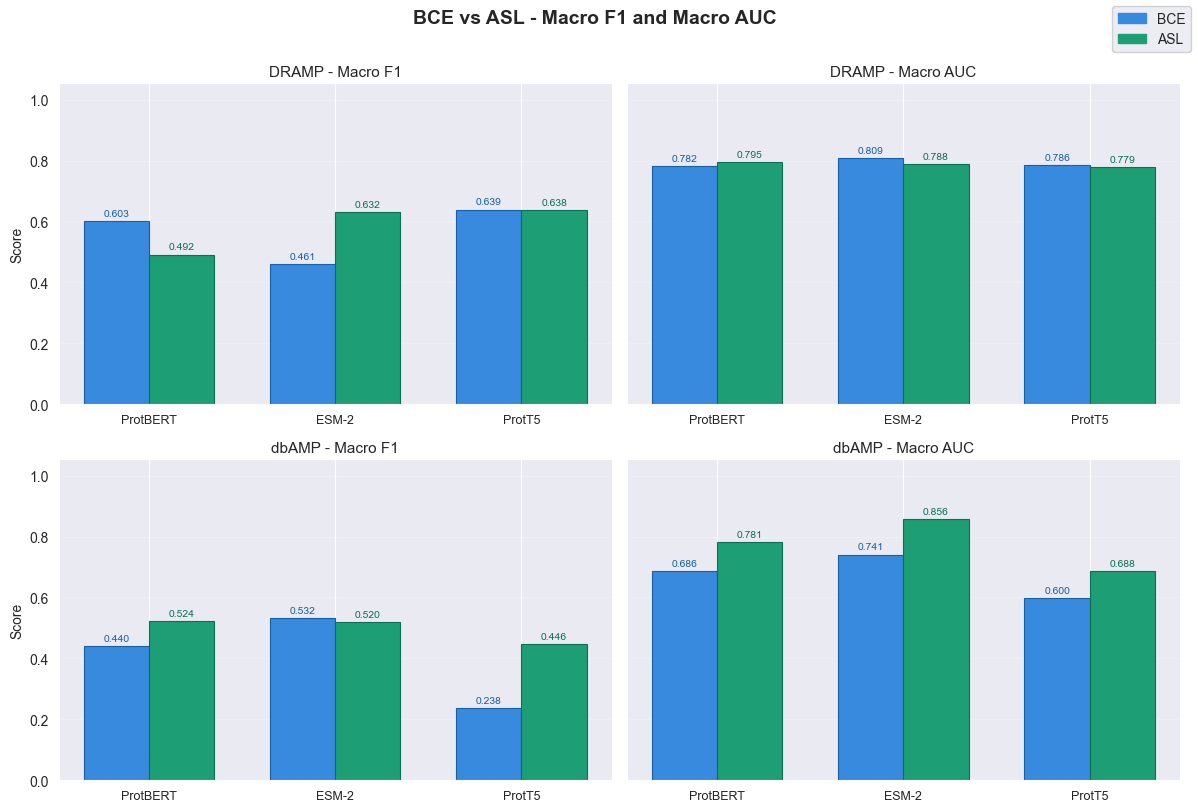

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

asl = pd.read_csv("../results/ASL/all_results.csv")
bce = pd.read_csv("../results/BCE/all_results.csv")

models = ["ProtBERT", "ESM-2", "ProtT5"]
labels = [ "ProtBERT", "ESM-2", "ProtT5"]
datasets = ["DRAMP", "dbAMP"]
metrics = ["Macro_F1", "Macro_AUC"]
metric_labels = ["Macro F1", "Macro AUC"]

BCE_COLOR = "#378ADD"
ASL_COLOR = "#1D9E75"

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
fig.suptitle("BCE vs ASL - Macro F1 and Macro AUC", fontsize=14, fontweight="bold", y=1.01)

for row, dataset in enumerate(datasets):
    for col, (metric, metric_label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[row][col]

        bce_vals = [
            bce[(bce["Model"] == m) & (bce["Dataset"] == dataset)][metric].values[0]
            for m in models
        ]
        asl_vals = [
            asl[(asl["Model"] == m) & (asl["Dataset"] == dataset)][metric].values[0]
            for m in models
        ]

        bars_bce = ax.bar(x - width / 2, bce_vals, width, label="BCE",
                          color=BCE_COLOR, edgecolor="#185FA5", linewidth=0.8)
        bars_asl = ax.bar(x + width / 2, asl_vals, width, label="ASL",
                          color=ASL_COLOR, edgecolor="#0F6E56", linewidth=0.8)

        for bar in bars_bce:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5, color="#185FA5")
        for bar in bars_asl:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5, color="#0F6E56")

        ax.set_title(f"{dataset} - {metric_label}", fontsize=11)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Score" if col == 0 else "")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.3, linewidth=0.5)

legend_patches = [
    mpatches.Patch(color=BCE_COLOR, label="BCE"),
    mpatches.Patch(color=ASL_COLOR, label="ASL"),
]
fig.legend(handles=legend_patches, loc="upper right", fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig("bce_vs_asl.png", dpi=150, bbox_inches="tight")
plt.show()